In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df2 = pd.read_csv("/kaggle/input/t20-world-cup-2026-match-dataset/match_results.csv")
df1 = pd.read_csv("/kaggle/input/t20-world-cup-2026-match-dataset/Match_dataset.csv")

In [3]:
df1.head()

,Match_ID,Date,Venue,Team_A,Team_B,Stage,Team_A_Ranking,Team_B_Ranking,Team_A_Form,Team_B_Form,...,HeadToHead_B_Wins,Venue_HomeAdvantage_A,Venue_HomeAdvantage_B,Pitch_Type,Avg_T20_Score_Venue,Toss_Winner,Toss_Decision,Team_A_Tech_Index,Team_B_Tech_Index,Match_Total
0,M0001,2026-03-06,Chennai,New Zealand,Scotland,Super8,5,13,76.97,54.62,...,4,0,0,Spin-Friendly,155,Team_A,Field,251.27,156.37,168
1,M0002,2026-03-07,Mumbai,South Africa,Sri Lanka,Final,6,9,64.19,58.75,...,6,0,0,Flat,175,Team_B,Bat,249.33,187.44,150
2,M0003,2026-03-02,Kolkata,India,PNG,Group,1,20,69.87,45.14,...,0,1,0,Spin-Friendly,165,Team_B,Field,298.24,54.03,160
3,M0004,2026-02-22,Colombo,Netherlands,Ireland,Group,11,12,85.59,61.94,...,4,0,0,Spin-Friendly,160,Team_A,Bat,197.19,174.95,145
4,M0005,2026-02-28,Mumbai,Namibia,South Africa,Group,15,6,45.98,88.52,...,15,0,0,Flat,175,Team_B,Bat,124.91,271.68,185


In [4]:
df2.head()

,Match_ID,Winner
0,M0001,Team_A
1,M0002,Team_A
2,M0003,Team_A
3,M0004,Team_A
4,M0005,Team_B


In [5]:
df = df1.merge(df2, on="Match_ID", how="left")
df.head()

,Match_ID,Date,Venue,Team_A,Team_B,Stage,Team_A_Ranking,Team_B_Ranking,Team_A_Form,Team_B_Form,...,Venue_HomeAdvantage_A,Venue_HomeAdvantage_B,Pitch_Type,Avg_T20_Score_Venue,Toss_Winner,Toss_Decision,Team_A_Tech_Index,Team_B_Tech_Index,Match_Total,Winner
0,M0001,2026-03-06,Chennai,New Zealand,Scotland,Super8,5,13,76.97,54.62,...,0,0,Spin-Friendly,155,Team_A,Field,251.27,156.37,168,Team_A
1,M0002,2026-03-07,Mumbai,South Africa,Sri Lanka,Final,6,9,64.19,58.75,...,0,0,Flat,175,Team_B,Bat,249.33,187.44,150,Team_A
2,M0003,2026-03-02,Kolkata,India,PNG,Group,1,20,69.87,45.14,...,1,0,Spin-Friendly,165,Team_B,Field,298.24,54.03,160,Team_A
3,M0004,2026-02-22,Colombo,Netherlands,Ireland,Group,11,12,85.59,61.94,...,0,0,Spin-Friendly,160,Team_A,Bat,197.19,174.95,145,Team_A
4,M0005,2026-02-28,Mumbai,Namibia,South Africa,Group,15,6,45.98,88.52,...,0,0,Flat,175,Team_B,Bat,124.91,271.68,185,Team_B


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Match_ID               600 non-null    object 
 1   Date                   600 non-null    object 
 2   Venue                  600 non-null    object 
 3   Team_A                 600 non-null    object 
 4   Team_B                 600 non-null    object 
 5   Stage                  600 non-null    object 
 6   Team_A_Ranking         600 non-null    int64  
 7   Team_B_Ranking         600 non-null    int64  
 8   Team_A_Form            600 non-null    float64
 9   Team_B_Form            600 non-null    float64
 10  HeadToHead_A_Wins      600 non-null    int64  
 11  HeadToHead_B_Wins      600 non-null    int64  
 12  Venue_HomeAdvantage_A  600 non-null    int64  
 13  Venue_HomeAdvantage_B  600 non-null    int64  
 14  Pitch_Type             600 non-null    object 
 15  Avg_T2

In [7]:
df.head()

,Match_ID,Date,Venue,Team_A,Team_B,Stage,Team_A_Ranking,Team_B_Ranking,Team_A_Form,Team_B_Form,...,Venue_HomeAdvantage_A,Venue_HomeAdvantage_B,Pitch_Type,Avg_T20_Score_Venue,Toss_Winner,Toss_Decision,Team_A_Tech_Index,Team_B_Tech_Index,Match_Total,Winner
0,M0001,2026-03-06,Chennai,New Zealand,Scotland,Super8,5,13,76.97,54.62,...,0,0,Spin-Friendly,155,Team_A,Field,251.27,156.37,168,Team_A
1,M0002,2026-03-07,Mumbai,South Africa,Sri Lanka,Final,6,9,64.19,58.75,...,0,0,Flat,175,Team_B,Bat,249.33,187.44,150,Team_A
2,M0003,2026-03-02,Kolkata,India,PNG,Group,1,20,69.87,45.14,...,1,0,Spin-Friendly,165,Team_B,Field,298.24,54.03,160,Team_A
3,M0004,2026-02-22,Colombo,Netherlands,Ireland,Group,11,12,85.59,61.94,...,0,0,Spin-Friendly,160,Team_A,Bat,197.19,174.95,145,Team_A
4,M0005,2026-02-28,Mumbai,Namibia,South Africa,Group,15,6,45.98,88.52,...,0,0,Flat,175,Team_B,Bat,124.91,271.68,185,Team_B


In [8]:
df['Winner'].value_counts()
df['Winner'].value_counts(normalize=True)

Winner
Team_A    0.53
Team_B    0.47
Name: proportion, dtype: float64

In [9]:
df.groupby('Winner')[['Team_A_Ranking','Team_B_Ranking']].mean()


,Team_A_Ranking,Team_B_Ranking
Winner,,
Team_A,7.669811,13.122642
Team_B,13.861702,7.255319


### What this clearly shows
#### When Team_A wins:
- Team_A has much better ranking (lower is better)
- Team_B is relatively weaker

#### When Team_B wins:
- Team_B has much better ranking
- Team_A is weaker

## Distribution Plots (Numerical Features)
### Ranking Difference Distribution

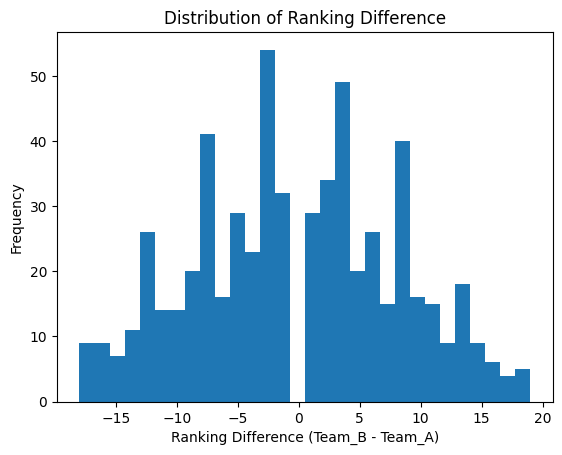

In [10]:
df['Winner_enc'] = df['Winner'].map({'Team_A': 1, 'Team_B': 0})
df['Ranking_Diff'] = df['Team_B_Ranking'] - df['Team_A_Ranking']
df.groupby('Winner')['Ranking_Diff'].mean()


plt.hist(df['Ranking_Diff'], bins=30)
plt.xlabel('Ranking Difference (Team_B - Team_A)')
plt.ylabel('Frequency')
plt.title('Distribution of Ranking Difference')
plt.show()

### Form Difference Distribution

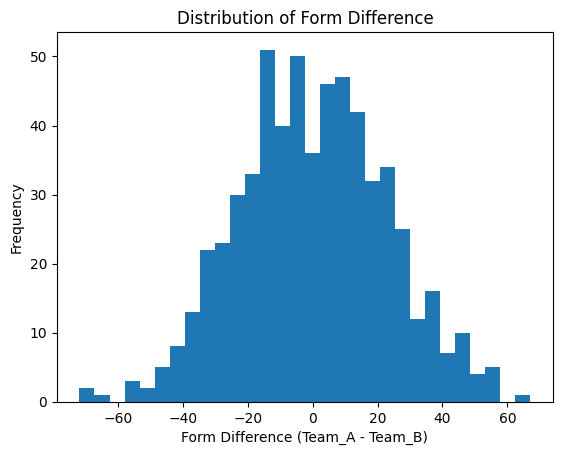

In [11]:
df['Form_Diff'] = df['Team_A_Form'] - df['Team_B_Form']
df.groupby('Winner')['Form_Diff'].mean()
plt.hist(df['Form_Diff'], bins=30)
plt.xlabel('Form Difference (Team_A - Team_B)')
plt.ylabel('Frequency')
plt.title('Distribution of Form Difference')
plt.show()

### Tech Index Difference

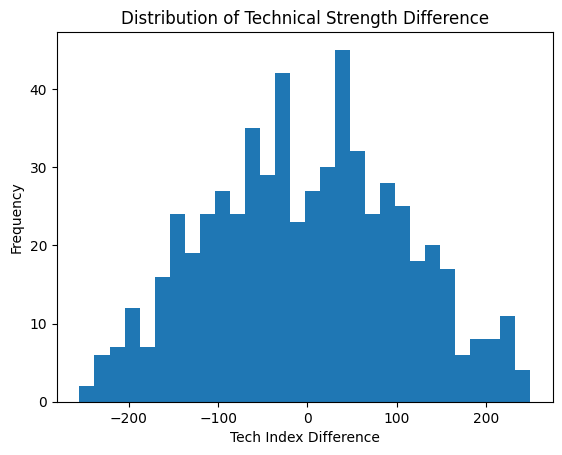

In [12]:
df['Tech_Diff'] = df['Team_A_Tech_Index'] - df['Team_B_Tech_Index']
df.groupby('Winner')['Tech_Diff'].mean()
plt.hist(df['Tech_Diff'], bins=30)
plt.xlabel('Tech Index Difference')
plt.ylabel('Frequency')
plt.title('Distribution of Technical Strength Difference')
plt.show()

## Boxplots: Feature vs Winner
### Ranking Difference vs Winner

/tmp/ipykernel_17/3128484536.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


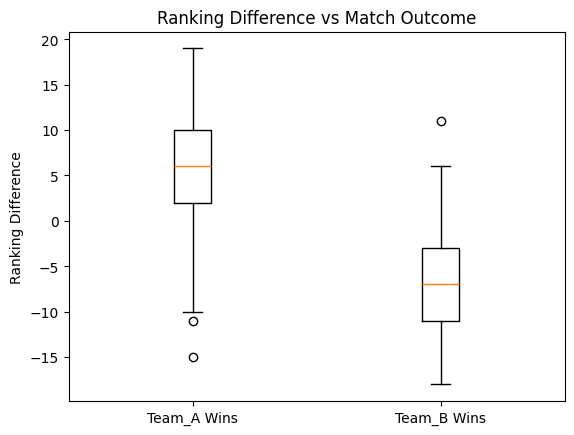

In [13]:
plt.boxplot(
    [df[df['Winner']=='Team_A']['Ranking_Diff'],
     df[df['Winner']=='Team_B']['Ranking_Diff']],
    labels=['Team_A Wins','Team_B Wins']
)
plt.ylabel('Ranking Difference')
plt.title('Ranking Difference vs Match Outcome')
plt.show()

### Form Difference vs Winner

/tmp/ipykernel_17/3952124321.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


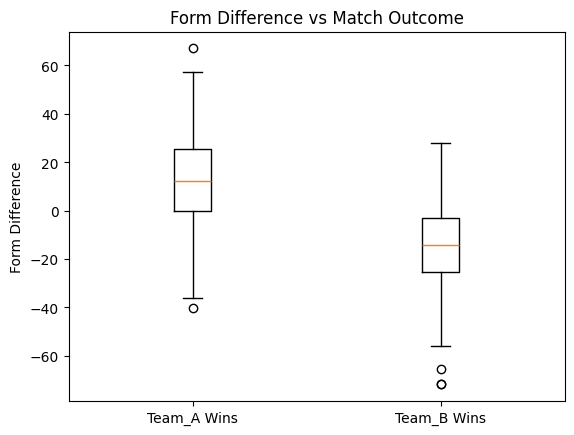

In [14]:
plt.boxplot(
    [df[df['Winner']=='Team_A']['Form_Diff'],
     df[df['Winner']=='Team_B']['Form_Diff']],
    labels=['Team_A Wins','Team_B Wins']
)
plt.ylabel('Form Difference')
plt.title('Form Difference vs Match Outcome')
plt.show()

## Categorical EDA Plots
### Pitch Type vs Win Percentage

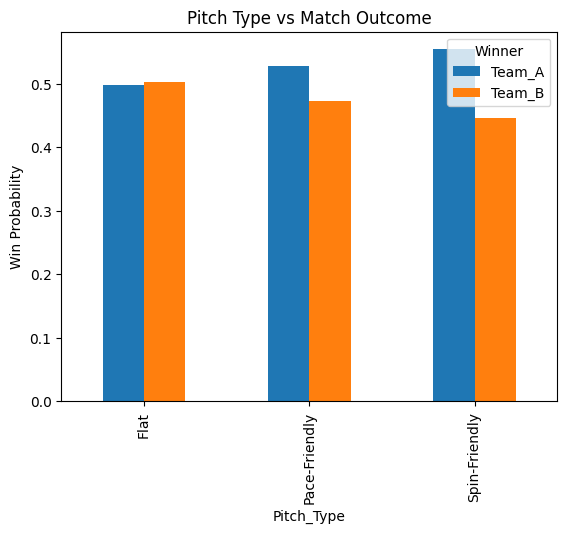

In [15]:
pd.crosstab(df['Pitch_Type'], df['Winner'], normalize='index').plot(kind='bar')
plt.ylabel('Win Probability')
plt.title('Pitch Type vs Match Outcome')
plt.show()

## Toss Decision Impact

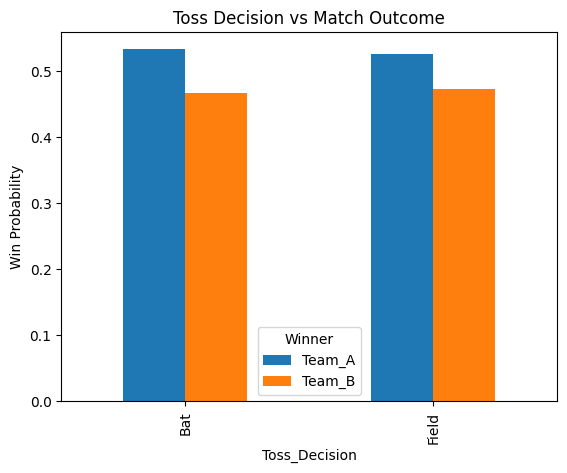

In [16]:
pd.crosstab(df['Toss_Decision'], df['Winner'], normalize='index').plot(kind='bar')
plt.ylabel('Win Probability')
plt.title('Toss Decision vs Match Outcome')
plt.show()

## Correlation Matrix (Numerical Only)

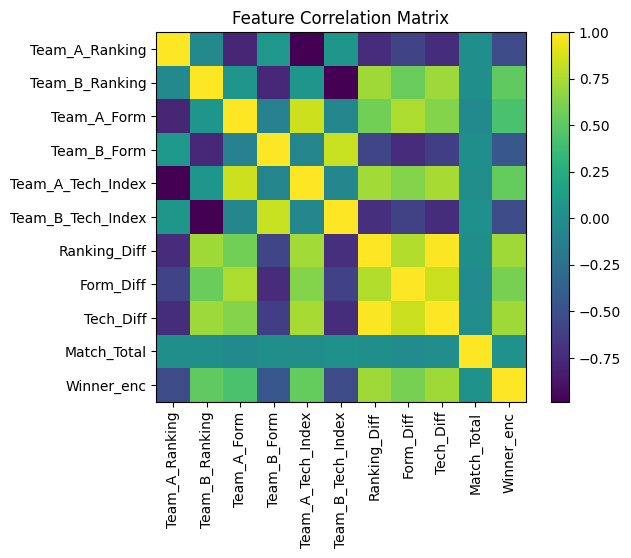

In [17]:
corr_features = [
    'Team_A_Ranking','Team_B_Ranking',
    'Team_A_Form','Team_B_Form',
    'Team_A_Tech_Index','Team_B_Tech_Index',
    'Ranking_Diff','Form_Diff','Tech_Diff',
    'Match_Total','Winner_enc'
]

corr = df[corr_features].corr()

import matplotlib.pyplot as plt

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.show()
